## Textbook Code
- 이전에 거의 만점가까이 나왔던 것에 비하면, train-tesst 모두 상당히 낮아졌네?

In [15]:
# coding: utf-8
import os
import sys
sys.path.append('./official_github/')  # 부모 디렉터리의 파일을 가져올 수 있도록 설정
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net_extend import MultiLayerNetExtend
from common.trainer import Trainer

In [16]:
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 오버피팅을 재현하기 위해 학습 데이터 수를 줄임
x_train = x_train[:300]
t_train = t_train[:300]

# 드롭아웃 사용 유무와 비울 설정 ========================
use_dropout = True  # 드롭아웃을 쓰지 않을 때는 False
dropout_ratio = 0.2
# ====================================================

network = MultiLayerNetExtend(input_size=784,
                              hidden_size_list=[100, 100, 100, 100, 100, 100],
                              output_size=10, use_dropout=use_dropout,
                              dropout_ration=dropout_ratio)
trainer = Trainer(network, x_train, t_train, x_test, t_test,
                  epochs=301, mini_batch_size=100,
                  optimizer='sgd', optimizer_param={'lr': 0.01}, verbose=True)
trainer.train()

train_acc_list, test_acc_list = trainer.train_acc_list, trainer.test_acc_list

# 그래프 그리기==========

# epoch:301, train acc:0.73, test acc:0.6315


7930
7983
8010
8031
7971
8006
train loss:2.3177119078691124
=== epoch:1, train acc:0.10666666666666667, test acc:0.1028 ===
7985
7994
8005
8003
8006
8032
train loss:2.3115541377157722
8004
8007
8014
7984
7993
7987
train loss:2.335823689622508
8096
8081
7940
7974
7973
7987
train loss:2.322782656084813
=== epoch:2, train acc:0.10666666666666667, test acc:0.1034 ===
7997
8065
8010
8009
7976
8009
train loss:2.3131997074142716
8032
7981
8050
8004
7981
7963
train loss:2.3333960107116622
8053
8037
7941
7999
7996
7994
train loss:2.318596137571277
=== epoch:3, train acc:0.11, test acc:0.1041 ===
8039
7995
8031
8036
8054
7994
train loss:2.309096750238996
7975
8020
8019
7998
7987
8002
train loss:2.2980666064032405
8041
7972
7934
8003
8013
7982
train loss:2.323581337622971
=== epoch:4, train acc:0.10666666666666667, test acc:0.104 ===
8048
8004
7950
8027
8001
7960
train loss:2.2755571769506364
8038
7942
8047
7955
8062
7940
train loss:2.27250963922093
7968
8003
7992
8014
7987
7992
train loss:2.2964

In [26]:
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 오버피팅을 재현하기 위해 학습 데이터 수를 줄임
x_train = x_train[:300]
t_train = t_train[:300]

# 드롭아웃 사용 유무와 비울 설정 ========================
use_dropout = False  # 드롭아웃을 쓰지 않을 때는 False
dropout_ratio = 0.2
# ====================================================

network = MultiLayerNetExtend(input_size=784,
                              hidden_size_list=[100, 100, 100, 100, 100, 100],
                              output_size=10, use_dropout=use_dropout,
                              dropout_ration=dropout_ratio)
trainer = Trainer(network, x_train, t_train, x_test, t_test,
                  epochs=301, mini_batch_size=100,
                  optimizer='sgd', optimizer_param={'lr': 0.01}, verbose=True)
trainer.train()

no_train_acc_list, no_test_acc_list = trainer.train_acc_list, trainer.test_acc_list

# 그래프 그리기==========

# epoch:301, train acc:0.73, test acc:0.6315


train loss:2.330480180065483
=== epoch:1, train acc:0.11333333333333333, test acc:0.1197 ===
train loss:2.2357186620440586
train loss:2.2096262477285644
train loss:2.250980291449305
=== epoch:2, train acc:0.14333333333333334, test acc:0.1371 ===
train loss:2.2594888691107915
train loss:2.2312358835670754
train loss:2.1857336059748547
=== epoch:3, train acc:0.19333333333333333, test acc:0.1707 ===
train loss:2.2243640528251647
train loss:2.1351583558782554
train loss:2.1493980512436583
=== epoch:4, train acc:0.25, test acc:0.2003 ===
train loss:2.20618846683397
train loss:2.1787363992552162
train loss:2.108941068397734
=== epoch:5, train acc:0.30333333333333334, test acc:0.2461 ===
train loss:2.095972986689404
train loss:2.0815817597340858
train loss:2.142497107670168
=== epoch:6, train acc:0.35, test acc:0.2813 ===
train loss:2.049054691605925
train loss:2.0384075938729738
train loss:2.025733461285817
=== epoch:7, train acc:0.38666666666666666, test acc:0.2996 ===
train loss:2.00364105

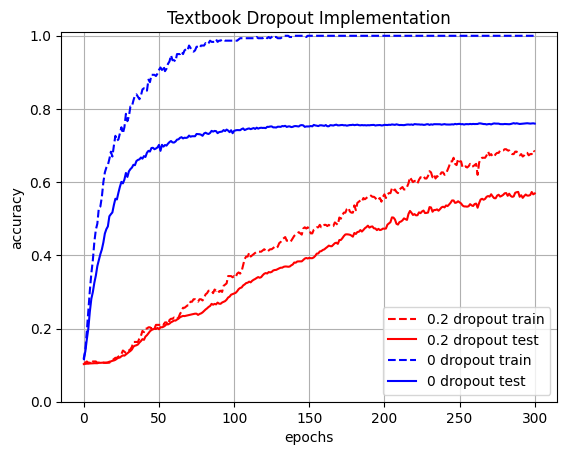

In [29]:
markers = {'train': 'o', 'test': 's'}
x = np.arange(len(train_acc_list))
plt.plot(x, train_acc_list, label='0.2 dropout train', linestyle='dashed', color='r')
plt.plot(x, test_acc_list, label='0.2 dropout test', linestyle='solid', color='r')
plt.plot(x, no_train_acc_list, label='0 dropout train', linestyle='dashed', color='b')
plt.plot(x, no_test_acc_list, label='0 dropout test', linestyle='solid', color='b')
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.title('Textbook Dropout Implementation')
plt.ylim(0, 1.01)
plt.legend(loc='lower right')
plt.grid()
plt.show()

## My code

In [18]:
import sys, os
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

sys.path.append('./official_github/')
from dataset.mnist import load_mnist
from my_models import MultiLayerNet, SGD

In [19]:
(x_train, t_train), (x_test, t_test) = load_mnist(True)
x_train = x_train[:300]
t_train = t_train[:300]

max_epochs = 301
train_size = x_train.shape[0]
batch_size = 100
iter_per_epoch = max(train_size / batch_size, 1)

use_dropout = True
dropout_ratio = 0.2

network = MultiLayerNet(784, [100, 100, 100, 100, 100, 100], 10,
                        dropout=use_dropout, dropout_ratio=dropout_ratio)


In [20]:
outputs_dict = defaultdict(list)

for dropout_ratio in (0, 0.2, 0.5, 0.7):
    network = MultiLayerNet(784, [100, 100, 100, 100, 100, 100], 10,
                            dropout=True, dropout_ratio=dropout_ratio)
    optimizer= SGD(lr=0.01)

    epoch_cnt = 0
    for i in range(1000000000):
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]

        grads = network.gradient(x_batch, t_batch)
        optimizer.update(network.params, grads)

        if i % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, t_train)
            test_acc = network.accuracy(x_test, t_test)
            outputs_dict[f'{dropout_ratio} dropout train_acc'].append(train_acc)
            outputs_dict[f'{dropout_ratio} dropout test_acc'].append(test_acc)

            print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

            epoch_cnt += 1
            if epoch_cnt >= max_epochs:
                break

10000
10000
10000
10000
10000
10000
epoch:0, train acc:0.10666666666666667, test acc:0.1004
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
epoch:1, train acc:0.14666666666666667, test acc:0.1154
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
epoch:2, train acc:0.19, test acc:0.1275
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
epoch:3, train acc:0.22666666666666666, test acc:0.1493
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
epoch:4, train acc:0.24, test acc:0.1743
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
epoch:5, train acc:0.25666666666666665, test acc:0.1957
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
10000
epoch:6, t

Text(0.5, 1.0, 'My dropout implementaton')

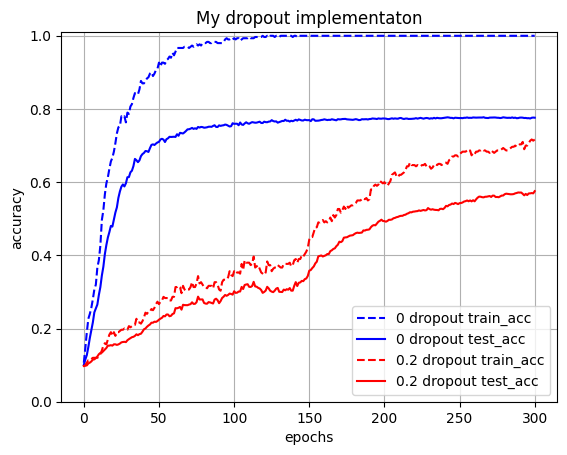

In [24]:
for key, value in outputs_dict.items():
    color = 'r' if key.startswith('0.2') else 'b'
    plt.plot(value, label=key, color=color, linestyle=('dashed' if 'train' in key else 'solid'))
plt.legend()
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.01)
plt.legend(loc='lower right')
plt.grid()
plt.title('My dropout implementaton')